# Simulating Asset Prices

In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import opstrat as op
# Set max row to 300
pd.set_option('display.max_rows', 300)

In [2]:
class MonteCarloOptionPricing:
    '''Monte Carlo Option Pricing Engine'''
    def __init__(self, S0:float, strike:float, rate:float, sigma:float, dte:float, nsim:int, timesteps:int=252) -> float:
        self.S0 = S0
        self.K = strike
        self.r = rate
        self.sigma = sigma
        self.T = dte
        self.N = nsim
        self.ts = timesteps
        self.df = np.exp(-self.r * self.T)

    @property
    def psuedorandomnumber(self):
        '''generate psuedo random numbers''' 
        return np.random.standard_normal(self.N)

    @property
    def simulatepath(self):
        '''simulate price path''' 
        np.random.seed(2024) 
        # define dt
        dt = self.T/self.ts  
        # simulate path
        S = np.zeros((self.ts, self.N))
        S[0] = self.S0
        
        for i in range(0, self.ts-1):
            w = self.psuedorandomnumber
            S[i+1] = S[i] * (1+ self.r*dt + self.sigma * np.sqrt(dt)*w)
        return S

    'European option'
    @property
    def vanillaoption(self):
        '''calculate vanilla option payoff''' 
        S = self.simulatepath
        # calculate the discounted value of the expected payoff
        vanilla_call = np.exp(-self.r*self.T) * np.mean(np.maximum(0, S[-1]-self.K))
        vanilla_put = np.exp(-self.r*self.T) * np.mean(np.maximum(0, self.K-S[-1]))
        return [vanilla_call, vanilla_put]

    
    @property
    def asianoption1(self):
        '''calculates asian option payoff for fixed strike''' 
        S = self.simulatepath
        # average the price across days
        A = S.mean(axis=0)
        # calculate the discounted value of the expeced payoff
        asian_call1 = np.exp(-self.r*self.T) * np.mean(np.maximum(0, A-self.K))
        asian_put1 = np.exp(-self.r*self.T) * np.mean(np.maximum(0, self.K-A))
        return [asian_call1, asian_put1]

    @property
    def asianoption2(self):
        '''calculates the asian option payoff for a floating strike''' 
        S = self.simulatepath
        # average the price across days
        A = S.mean(axis=0)
        # calculate the discounted value of the expeced payoff
        asian_call2 = np.exp(-self.r*self.T) * np.mean(np.maximum(0, S[-1]-A))
        asian_put2 = np.exp(-self.r*self.T) * np.mean(np.maximum(0, A-S[-1]))
        return [asian_call2, asian_put2]

    def upandoutcall(self, barrier:int=150, rebate:int=0) -> float: 
        '''calculate up-and-out barrier option payoff'''
        S = self.simulatepath
        # Barrier shift - continuity correction for discrete monitoring
        barriershift = barrier*np.exp(0.5826 * self.sigma * np.sqrt(self.T/self.ts))  
        value=0
        # Calculate the discounted value of the expected payoff 
        for i in range(self.N):
            if S[:,i].max() < barriershift:
                value += np.maximum(0, S[-1,i]-self.K)
            else:
                value += rebate
        return [np.exp(-self.r*self.T) * value/self.N, barriershift]

In [3]:
# instantiate option
mc = MonteCarloOptionPricing(100,100,0.05,0.2,1,100000)

# Verify the generated price paths
pd.DataFrame(mc.simulatepath).head(5)

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1,102.121383,100.948812,99.765928,99.829710,101.173958,101.481719,96.718999,98.350127,100.599372,100.148414,...,100.343690,101.838621,99.128963,100.129858,97.246274,99.603550,101.377545,99.498750,98.363364,99.097818
2,102.800486,100.691502,98.879648,100.485348,102.676310,103.384534,94.586061,97.245377,99.960900,98.209003,...,101.832121,101.904840,99.708843,98.986837,99.290424,100.373963,100.829959,100.373423,98.726274,98.158602
3,102.899333,101.160795,100.634882,100.042283,104.592883,103.999462,93.301903,98.718500,100.119254,99.519953,...,102.080752,100.559295,100.304167,99.350055,97.804600,99.662361,101.043296,99.975732,96.888125,98.108095
4,100.630016,100.314948,100.619516,99.688028,104.044243,103.234272,94.420157,100.468382,100.267392,101.185793,...,102.491424,100.531412,100.792401,102.538694,97.074667,98.107278,100.600329,99.932733,96.942377,98.546402


In [4]:
# Verify the generated price paths
pd.DataFrame(mc.simulatepath).tail(5)

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
247,141.054652,122.791158,89.566210,144.420546,124.502221,81.608672,118.582337,125.213451,111.370700,163.616408,...,105.511376,104.793360,113.620031,126.817955,116.126970,91.832957,71.054277,77.661827,114.199050,101.661136
248,140.871289,121.634601,89.524478,143.926665,125.659806,82.726409,116.420233,125.031747,113.980359,167.844427,...,105.544838,107.478260,114.607188,125.984933,116.180129,91.682329,70.611237,77.668729,115.461238,102.827802
249,139.482176,119.628915,89.096570,146.563297,125.570536,82.789684,113.733978,124.484349,116.135251,162.605067,...,105.772624,108.640166,115.468779,125.960005,114.816812,91.046136,70.878301,77.841094,114.007537,103.002838
250,141.437673,119.854615,90.473423,147.121107,124.461143,83.101166,111.542425,124.106212,116.674454,163.886254,...,105.746454,107.471261,115.694412,123.081588,113.559476,90.912640,70.243959,77.676287,112.050906,103.906380
251,142.982456,120.072472,90.316633,148.781911,122.771249,84.048953,113.849639,124.499340,117.936273,167.296821,...,106.739564,106.694851,115.834640,123.167677,112.881114,91.791613,70.620528,76.259556,112.470420,103.800921


#### Histogram of Psuedo Random Numbers

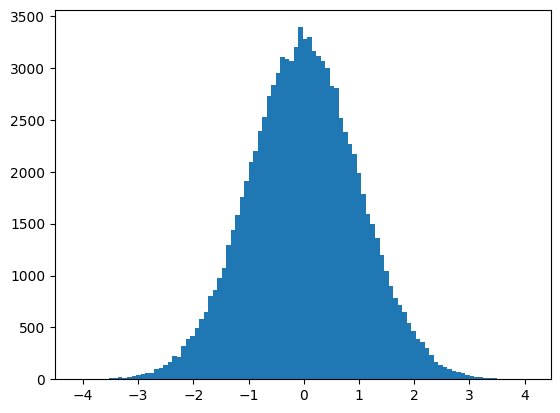

In [5]:
# Plot the histogram
plt.hist(mc.psuedorandomnumber, bins=100);

In [6]:
mc.psuedorandomnumber.mean(), mc.psuedorandomnumber.std()

(0.0014307335035334122, 1.0016654392481354)

#### Histogram of Simulated Paths

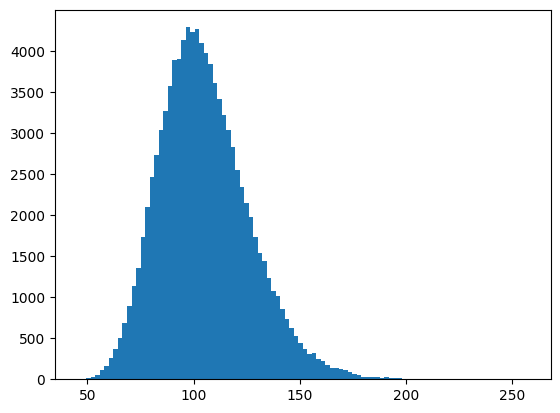

In [7]:
# Plot the histogram of the simulated price path at maturity

plt.hist(mc.simulatepath[-1], bins=100);

#### Visualization of Simulated Paths

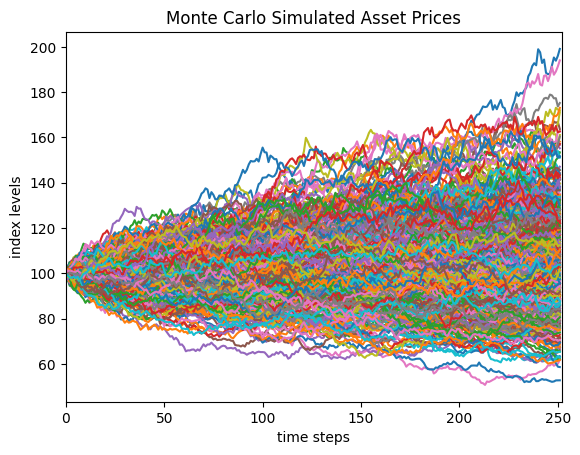

In [8]:
# Plot initial 100 simulated path using matplotlib
plt.plot(mc.simulatepath[:,-500:])
plt.xlabel('time steps')
plt.xlim(0,252)
plt.ylabel('index levels')
plt.title('Monte Carlo Simulated Asset Prices');

# Risk-Neutral Valuation

### European Option

In [9]:
# Get option values
print(f"European Call Option Value is {mc.vanillaoption[0]:0.4f}")
print(f"European Put Option Value is {mc.vanillaoption[1]:0.4f}")

European Call Option Value is 10.4352
European Put Option Value is 5.5305


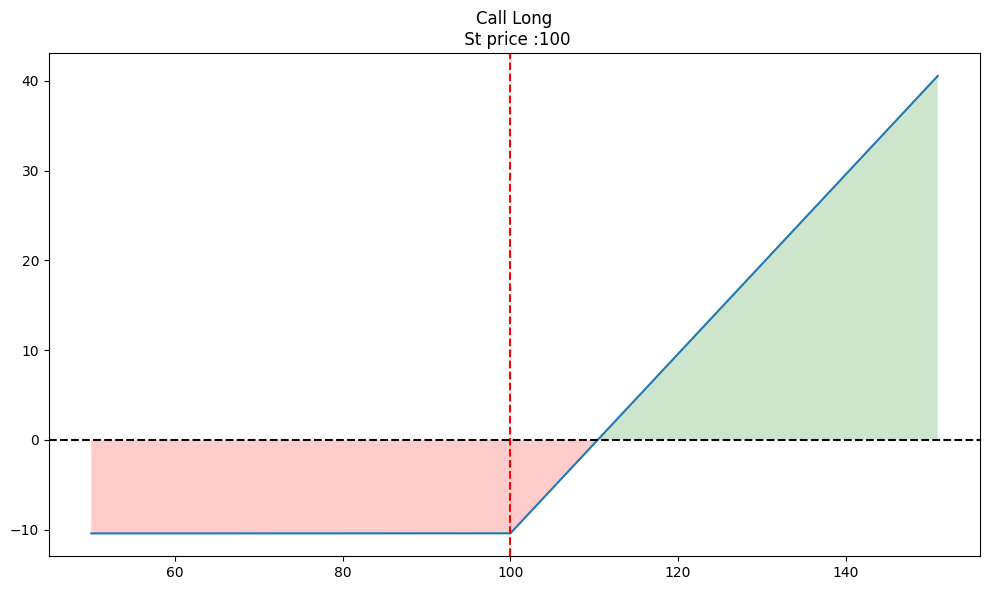

In [10]:
# Plot long call option payoff European Option
op.single_plotter(
    op_type='c',
    spot=mc.S0,
    spot_range=50,
    strike=mc.K,
    tr_type='b',
    op_pr=mc.vanillaoption[0],
)

#### Plot Payoff

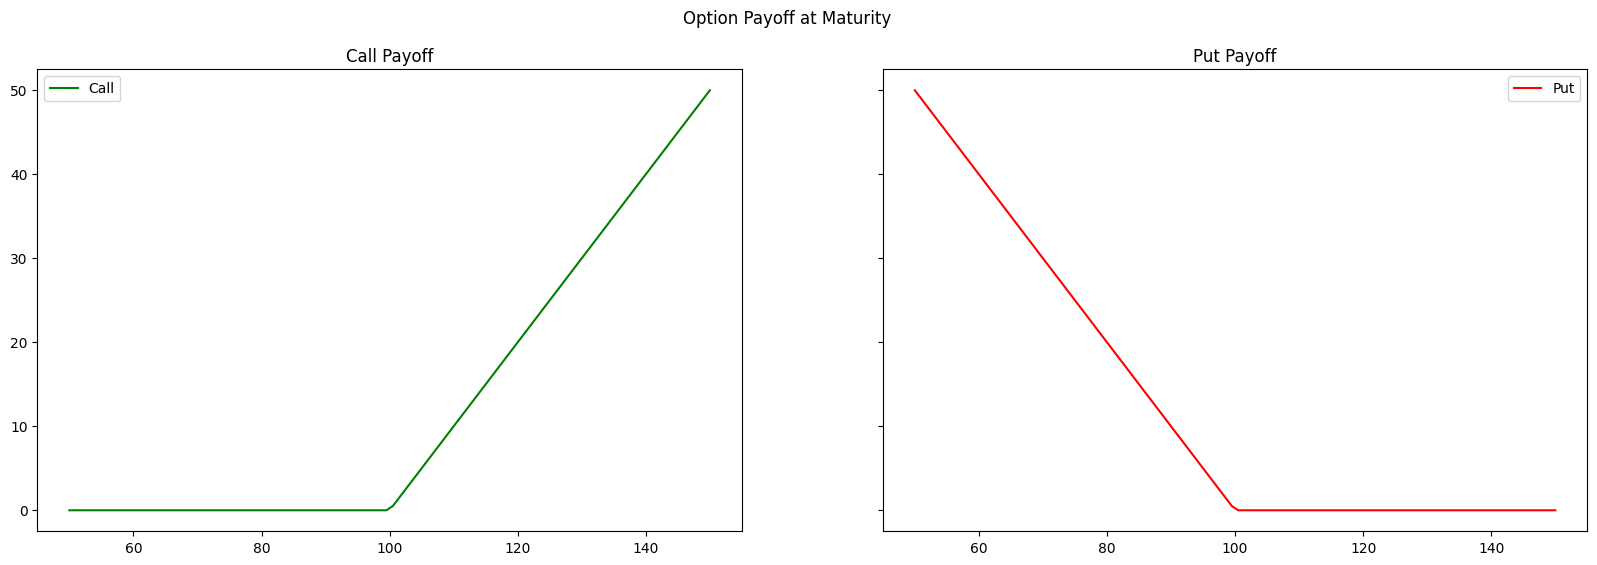

In [11]:
# range of spot prices
sT= np.linspace(50,150,100)
# visualize call and put price for range of spot prices
figure, axes = plt.subplots(1,2, figsize=(20,6), sharey=True)
title, payoff, color, label = ['Call Payoff', 'Put Payoff'], [np.maximum(sT-mc.K, 0), np.maximum(mc.K-sT, 0)], ['green', 'red'], ['Call', 'Put']

# plot payoff
for i in range(2):
    axes[i].plot(sT, payoff[i], color=color[i], label=label[i])
    axes[i].set_title(title[i])
    axes[i].legend()
    
figure.suptitle('Option Payoff at Maturity');

### Asian Call Option

In [11]:
# Get option values for fixed strike Asian
print(f"Asian Call Option Value is {mc.asianoption1[0]:0.4f}")
print(f"Asian Put Option Value is {mc.asianoption1[1]:0.4f}")

Asian Call Option Value is 5.7251
Asian Put Option Value is 3.3246


In [12]:
# Get option values for floating strike Asian
print(f"Asian Call Option Value is {mc.asianoption2[0]:0.4f}")
print(f"Asian Put Option Value is {mc.asianoption2[1]:0.4f}")

Asian Call Option Value is 5.8715
Asian Put Option Value is 3.3673


### Barrier Call Option

In [13]:
mc.upandoutcall(barrier=150, rebate =10)

[8.466077954033485, 151.10506116164294]

In [14]:
# Get barrier option valaues for B=150 and rebate=0
print(f"Up-and-Out Barrier Call Option Value is {mc.upandoutcall()[0]:0.4f}")

Up-and-Out Barrier Call Option Value is 8.0192


#### Plot Payoff

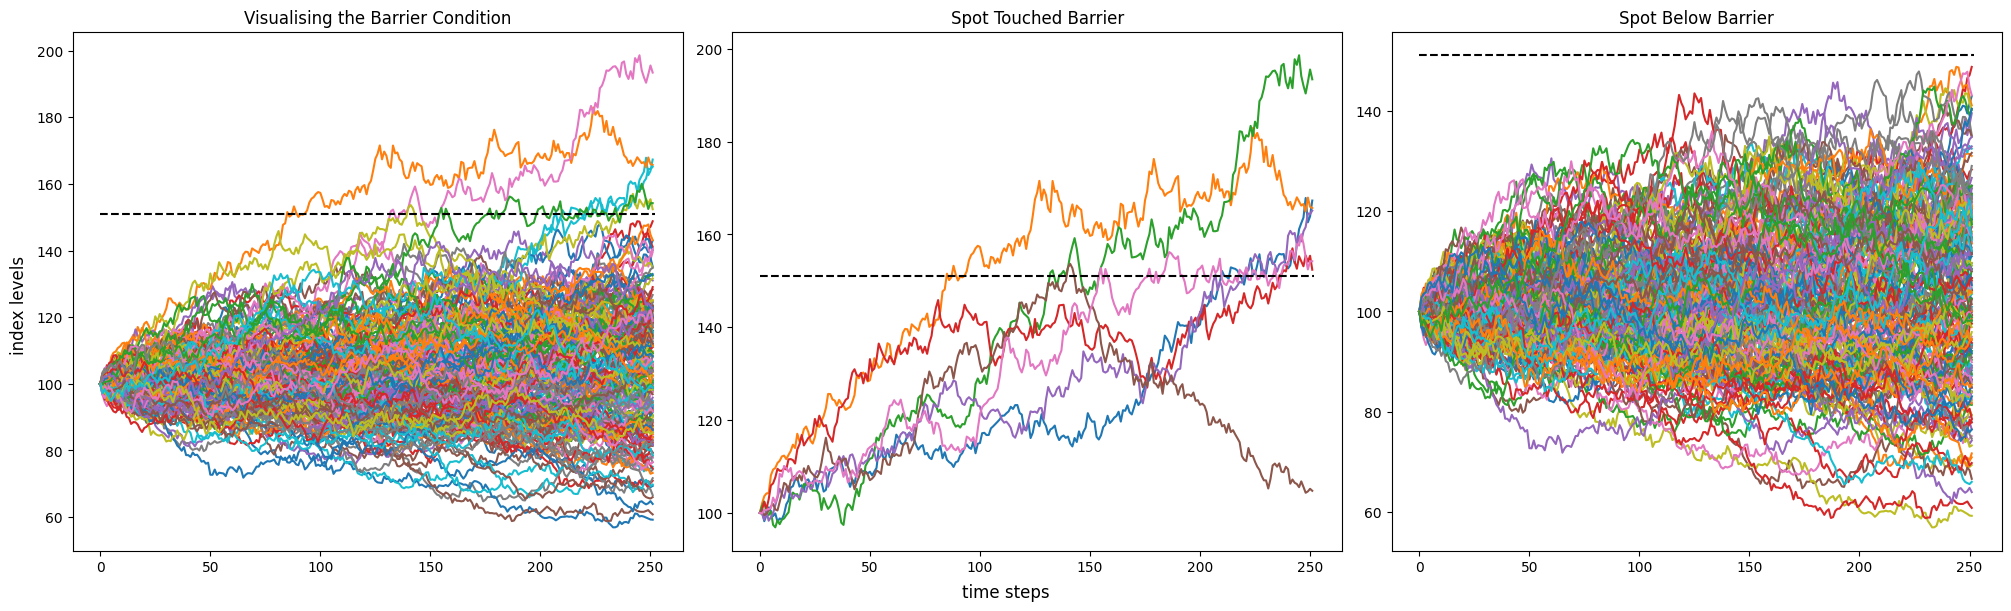

In [15]:
figure, axes = plt.subplots(1,3, figsize=(20,6), constrained_layout=True)
title = ['Visualising the Barrier Condition', 'Spot Touched Barrier', 'Spot Below Barrier']
# Get simulated path
S = mc.simulatepath
B_shift = mc.upandoutcall()[1]
axes[0].plot(S[:,:200])
for i in range(200):
    axes[1].plot(S[:,i]) if S[:,i].max() > B_shift else axes[2].plot(S[:,i])
for i in range(3):
    axes[i].set_title(title[i])
    axes[i].hlines(B_shift, 0, 252, colors='k', linestyles='dashed')
figure.supxlabel('time steps')
figure.supylabel('index levels')
plt.show()